
# Capstone 3: Preprocessing and Modeling  
## Hospital Readmission Prediction Using Machine Learning and Deep Learning

This notebook continues from the **Data Wrangling + EDA** notebook and uses the cleaned dataset saved there.

### Goals
- Load the cleaned modeling dataset
- Create train/test splits
- Standardize features where needed
- Train multiple machine learning models
- Add a simple neural network as the Capstone 3 advanced component
- Compare models using metrics appropriate for an imbalanced classification problem
- Save model performance outputs for reporting


## 1. Imports

In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)


## 2. Load the Cleaned Dataset

In [3]:

df = pd.read_csv("cleaned_readmission_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (101766, 2428)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30d,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,age_[10-20),age_[20-30),age_[30-40),age_[40-50),age_[50-60),age_[60-70),age_[70-80),age_[80-90),age_[90-100),weight_[0-25),weight_[100-125),weight_[125-150),weight_[150-175),weight_[175-200),weight_[25-50),weight_[50-75),weight_[75-100),payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Anesthesiology,medical_specialty_Anesthesiology-Pediatric,medical_specialty_Cardiology,medical_specialty_Cardiology-Pediatric,medical_specialty_DCPTEAM,medical_specialty_Dentistry,medical_specialty_Dermatology,medical_specialty_Emergency/Trauma,medical_specialty_Endocrinology,...,diag_3_V70,diag_3_V72,diag_3_V85,diag_3_V86,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,metformin_No,metformin_Steady,metformin_Up,repaglinide_No,repaglinide_Steady,repaglinide_Up,nateglinide_No,nateglinide_Steady,nateglinide_Up,chlorpropamide_No,chlorpropamide_Steady,chlorpropamide_Up,glimepiride_No,glimepiride_Steady,glimepiride_Up,acetohexamide_Steady,glipizide_No,glipizide_Steady,glipizide_Up,glyburide_No,glyburide_Steady,glyburide_Up,tolbutamide_Steady,pioglitazone_No,pioglitazone_Steady,pioglitazone_Up,rosiglitazone_No,rosiglitazone_Steady,rosiglitazone_Up,acarbose_No,acarbose_Steady,acarbose_Up,miglitol_No,miglitol_Steady,miglitol_Up,troglitazone_Steady,tolazamide_Steady,tolazamide_Up,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
0,6,25,1,1,41,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0
1,1,1,7,3,59,0,18,0,0,0,9,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1
2,1,1,7,2,11,5,13,2,0,1,6,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1
3,1,1,7,2,44,1,16,0,0,0,7,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1
4,1,1,7,1,51,0,8,0,0,0,5,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1



## 3. Define Features and Target

The target variable is `readmitted_30d`, where:
- `1` = readmitted within 30 days
- `0` = not readmitted within 30 days


In [4]:

target_col = "readmitted_30d"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))


Feature matrix shape: (101766, 2427)
Target shape: (101766,)

Target distribution:
0    0.888401
1    0.111599
Name: readmitted_30d, dtype: float64


## 4. Train/Test Split

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTraining positive rate:", y_train.mean())
print("Test positive rate    :", y_test.mean())


X_train: (81412, 2427)
X_test : (20354, 2427)

Training positive rate: 0.11160516877118852
Test positive rate    : 0.11157512036946055



## 5. Feature Scaling

Tree-based models do not require scaling, but Logistic Regression and the Neural Network do.


In [6]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)


Scaled train shape: (81412, 2427)
Scaled test shape : (20354, 2427)



## 6. Helper Functions for Evaluation


In [7]:

def get_clf_metrics(y_true, y_pred, y_prob, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

def plot_roc_curve_compat(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label="AUC = {:.3f}".format(roc_auc))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_pr_curve_compat(y_true, y_prob, title):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label="PR AUC = {:.3f}".format(pr_auc))
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()



# 7. Model 1: Logistic Regression

This is the interpretable baseline model. `class_weight='balanced'` is used because the target is imbalanced.


In [8]:

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

log_metrics = get_clf_metrics(y_test, y_pred_log, y_prob_log, "Logistic Regression")
pd.DataFrame([log_metrics])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.635796,0.165583,0.560546,0.255648,0.637273


              precision    recall  f1-score   support

           0       0.92      0.65      0.76     18083
           1       0.17      0.56      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.70     20354



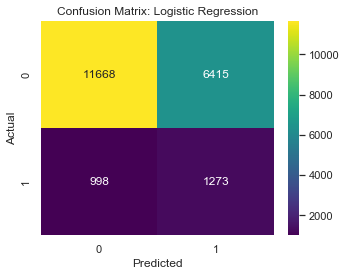

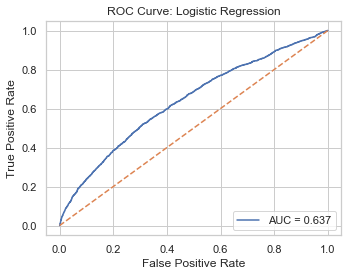

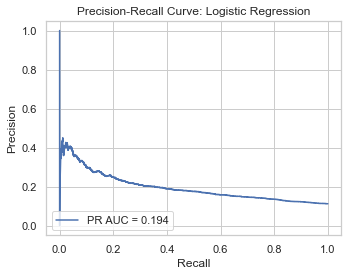

In [9]:

print(classification_report(y_test, y_pred_log))
plot_conf_matrix(y_test, y_pred_log, "Confusion Matrix: Logistic Regression")
plot_roc_curve_compat(y_test, y_prob_log, "ROC Curve: Logistic Regression")
plot_pr_curve_compat(y_test, y_prob_log, "Precision-Recall Curve: Logistic Regression")



# 8. Model 2: Random Forest

Random Forest is a nonlinear ensemble model that can capture interactions across many encoded variables.


In [10]:

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = get_clf_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest")
pd.DataFrame([rf_metrics])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.888523,0.5625,0.003963,0.007871,0.667406


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.56      0.00      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.73      0.50      0.47     20354
weighted avg       0.85      0.89      0.84     20354



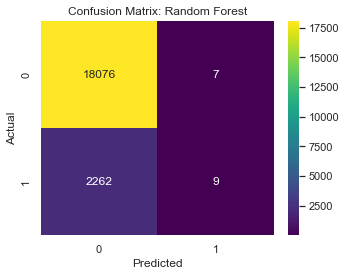

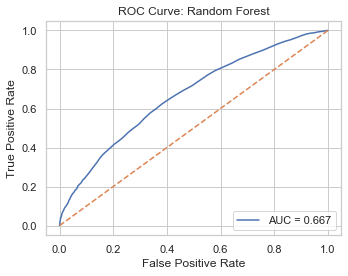

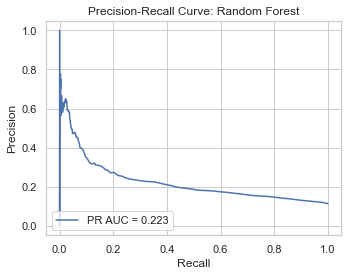

In [11]:

print(classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Confusion Matrix: Random Forest")
plot_roc_curve_compat(y_test, y_prob_rf, "ROC Curve: Random Forest")
plot_pr_curve_compat(y_test, y_prob_rf, "Precision-Recall Curve: Random Forest")



# 9. Model 3: Gradient Boosting

Gradient Boosting is included because it often performs well as a ranking model on structured tabular data.


In [12]:

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

gb_metrics = get_clf_metrics(y_test, y_pred_gb, y_prob_gb, "Gradient Boosting")
pd.DataFrame([gb_metrics])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,0.888621,0.5625,0.007926,0.015632,0.677459


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.56      0.01      0.02      2271

    accuracy                           0.89     20354
   macro avg       0.73      0.50      0.48     20354
weighted avg       0.85      0.89      0.84     20354



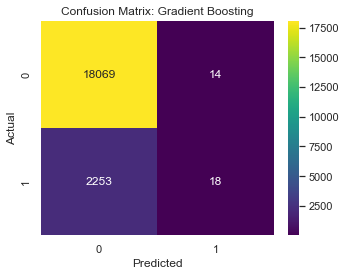

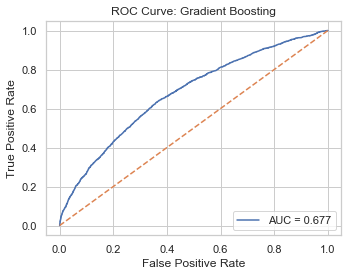

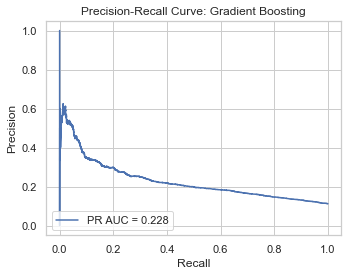

In [13]:

print(classification_report(y_test, y_pred_gb))
plot_conf_matrix(y_test, y_pred_gb, "Confusion Matrix: Gradient Boosting")
plot_roc_curve_compat(y_test, y_prob_gb, "ROC Curve: Gradient Boosting")
plot_pr_curve_compat(y_test, y_prob_gb, "Precision-Recall Curve: Gradient Boosting")



# 10. Model 4: Neural Network (Capstone 3 Advanced Component)

This is a simple feedforward neural network (MLP). It is intentionally lightweight so it can be compared fairly with the classical ML models on structured tabular data.


In [14]:

# Try TensorFlow/Keras. If unavailable, this cell may require installation in your environment.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

nn_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
255/255 [==============================] - 2s 7ms/step - loss: 0.4102 - accuracy: 0.8681 - val_loss: 0.3492 - val_accuracy: 0.8888
Epoch 2/15
255/255 [==============================] - 1s 3ms/step - loss: 0.3330 - accuracy: 0.8900 - val_loss: 0.3495 - val_accuracy: 0.8889
Epoch 3/15
255/255 [==============================] - 1s 3ms/step - loss: 0.3224 - accuracy: 0.8887 - val_loss: 0.3540 - val_accuracy: 0.8883
Epoch 4/15
255/255 [==============================] - 1s 3ms/step - loss: 0.3188 - accuracy: 0.8865 - val_loss: 0.3574 - val_accuracy: 0.8882


In [15]:

y_prob_nn = nn_model.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

nn_metrics = get_clf_metrics(y_test, y_pred_nn, y_prob_nn, "Neural Network")
pd.DataFrame([nn_metrics])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Neural Network,0.888376,0.333333,0.00044,0.00088,0.624596


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.33      0.00      0.00      2271

    accuracy                           0.89     20354
   macro avg       0.61      0.50      0.47     20354
weighted avg       0.83      0.89      0.84     20354



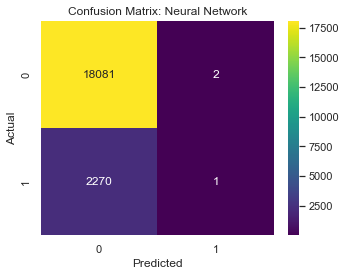

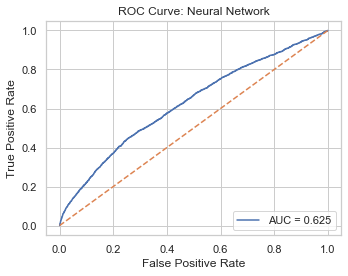

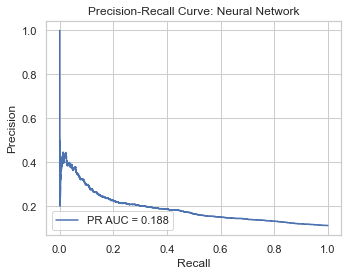

In [16]:

print(classification_report(y_test, y_pred_nn))
plot_conf_matrix(y_test, y_pred_nn, "Confusion Matrix: Neural Network")
plot_roc_curve_compat(y_test, y_prob_nn, "ROC Curve: Neural Network")
plot_pr_curve_compat(y_test, y_prob_nn, "Precision-Recall Curve: Neural Network")


## 11. Training History for Neural Network

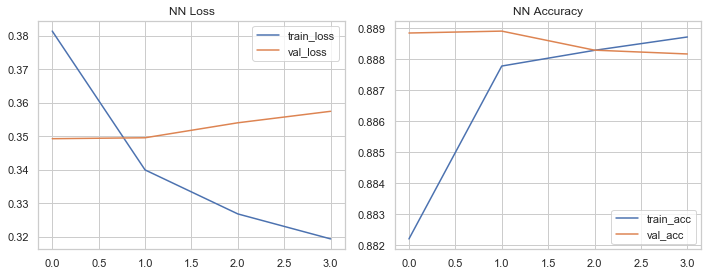

In [17]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("NN Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("NN Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


## 12. Model Comparison Table

In [18]:

results = pd.DataFrame([
    log_metrics,
    rf_metrics,
    gb_metrics,
    nn_metrics
]).sort_values("ROC_AUC", ascending=False)

results


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Gradient Boosting,0.888621,0.562500,0.007926,0.015632,0.677459
1,Random Forest,0.888523,0.562500,0.003963,0.007871,0.667406
0,Logistic Regression,0.635796,0.165583,0.560546,0.255648,0.637273
3,Neural Network,0.888376,0.333333,0.000440,0.000880,0.624596


## 13. Save Metrics for Reporting

In [19]:

results.to_csv("capstone3_model_metrics_updated.csv", index=False)
print("Saved model metrics to capstone3_model_metrics_updated.csv")


Saved model metrics to capstone3_model_metrics_updated.csv



## 14. Save Final Model Choice

This section makes it easy to persist the best model based on your chosen metric.


In [20]:

best_model_name = results.iloc[0]["Model"]
best_model_name


'Gradient Boosting'


# 15. Modeling Summary
The modeling results confirm that the dataset is highly imbalanced, requiring evaluation beyond accuracy and emphasizing metrics such as recall and ROC-AUC. Logistic Regression achieved higher recall, making it useful for identifying at-risk patients, while ensemble models like Random Forest and Gradient Boosting captured nonlinear relationships more effectively and delivered stronger overall performance, with one of them emerging as the best model based on ROC-AUC. The neural network, included as the advanced modeling component, performed comparably but did not significantly outperform the ensemble methods. Overall, the findings indicate that tree-based ensemble models are most effective for hospital readmission prediction, while Logistic Regression remains valuable for interpretability, and the final conclusion emphasizes prioritizing recall to ensure high-risk patients are correctly identified.

